# Data 4620 Homework 2

## Preprocessing

Load in UCI Optical Regocnition of Handwritten Digits dataset.

In [35]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [36]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [37]:
%pip install ucimlrepo


Note: you may need to restart the kernel to use updated packages.


In [38]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
optical_recognition_of_handwritten_digits = fetch_ucirepo(id=80) 
  
# data (as pandas dataframes) 
X = optical_recognition_of_handwritten_digits.data.features 
y = optical_recognition_of_handwritten_digits.data.targets 


General Information about the dataset

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Convert to arrays
X_array = np.asarray(X, dtype=np.float32)
y_array = np.asarray(y).ravel().astype(np.int64)

print("DATASET SUMMARY")
print("-" * 40)
print(f"Number of observations: {X_array.shape[0]:,}")
print(f"Number of features:     {X_array.shape[1]}")
print(f"Number of classes:      {len(np.unique(y_array))}")
print(f"Feature data type:      {X_array.dtype}")
print(f"Target data type:       {y_array.dtype}")
print(f"Minimum pixel value:    {X_array.min()}")
print(f"Maximum pixel value:    {X_array.max()}")
print(f"Missing feature values: {pd.isna(X_array).sum():,}")
print(f"Missing target values:  {pd.isna(y_array).sum():,}")

DATASET SUMMARY
----------------------------------------
Number of observations: 5,620
Number of features:     64
Number of classes:      10
Feature data type:      float32
Target data type:       int64
Minimum pixel value:    0.0
Maximum pixel value:    16.0
Missing feature values: 0
Missing target values:  0


In [40]:
# Class distribution
class_counts = (
    pd.Series(y_array, name="Digit")
    .value_counts()
    .sort_index()
    .rename("Count")
)

class_distribution = class_counts.to_frame()
class_distribution["Percent"] = (
    100 * class_distribution["Count"] / len(y_array)
).round(2)

display(class_distribution)


,Count,Percent
Digit,,
0,554,9.86
1,571,10.16
2,557,9.91
3,572,10.18
4,568,10.11
5,558,9.93
6,558,9.93
7,566,10.07
8,554,9.86


Create train, test, and validation splits and scale pixel values from 0 to 1.

In [41]:
from sklearn.model_selection import train_test_split

X_array = np.asarray(X, dtype=np.float32)
y_array = np.asarray(y).ravel().astype(np.int64)

# First hold out 20% as the final test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_array,
    y_array,
    test_size=0.20,
    random_state=42,
    stratify=y_array
)

# Use 20% of the remaining data for validation
# This gives approximately 64% train, 16% validation, 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=42,
    stratify=y_train_val
)

# Pixel values originally range from 0 to 16
X_train = X_train / 16.0
X_val = X_val / 16.0
X_test = X_test / 16.0

print(f"Training set:   {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set:       {X_test.shape}, {y_test.shape}")

print(f"\nTraining feature range: [{X_train.min():.1f}, {X_train.max():.1f}]")
print(f"Classes: {np.unique(y_train)}")

Training set:   (3596, 64), (3596,)
Validation set: (900, 64), (900,)
Test set:       (1124, 64), (1124,)

Training feature range: [0.0, 1.0]
Classes: [0 1 2 3 4 5 6 7 8 9]


## Modeling

Unregularized baseline.

In [42]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [43]:
import random
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Fix the random seeds so the experiment is reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Convert the preprocessed NumPy arrays to PyTorch datasets
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Plain MLP with no regularization
class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

baseline_model = BaselineMLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(baseline_model.parameters(), lr=0.05)

EPOCHS = 50
history = {
    "train_loss": [], "val_loss": [],
    "train_accuracy": [], "val_accuracy": []
}

for epoch in range(EPOCHS):
    baseline_model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for features, labels in train_loader:
        optimizer.zero_grad()
        logits = baseline_model(features)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * labels.size(0)
        train_correct += (logits.argmax(dim=1) == labels).sum().item()
        train_total += labels.size(0)

    baseline_model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            logits = baseline_model(features)
            loss = criterion(logits, labels)
            val_loss_sum += loss.item() * labels.size(0)
            val_correct += (logits.argmax(dim=1) == labels).sum().item()
            val_total += labels.size(0)

    history["train_loss"].append(train_loss_sum / train_total)
    history["val_loss"].append(val_loss_sum / val_total)
    history["train_accuracy"].append(train_correct / train_total)
    history["val_accuracy"].append(val_correct / val_total)

    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:02d}/{EPOCHS} | "
            f"train loss: {history['train_loss'][-1]:.4f}, "
            f"train accuracy: {history['train_accuracy'][-1]:.4f} | "
            f"val loss: {history['val_loss'][-1]:.4f}, "
            f"val accuracy: {history['val_accuracy'][-1]:.4f}"
        )


Epoch 01/50 | train loss: 2.2345, train accuracy: 0.2767 | val loss: 2.1182, val accuracy: 0.4689
Epoch 10/50 | train loss: 0.1522, train accuracy: 0.9572 | val loss: 0.1984, val accuracy: 0.9356
Epoch 20/50 | train loss: 0.0844, train accuracy: 0.9761 | val loss: 0.1529, val accuracy: 0.9567
Epoch 30/50 | train loss: 0.0606, train accuracy: 0.9828 | val loss: 0.1388, val accuracy: 0.9600
Epoch 40/50 | train loss: 0.0441, train accuracy: 0.9872 | val loss: 0.1330, val accuracy: 0.9622
Epoch 50/50 | train loss: 0.0340, train accuracy: 0.9936 | val loss: 0.1325, val accuracy: 0.9622


,Loss,Accuracy,Error Rate
Split,,,
Training,0.0337,99.22%,0.78%
Validation,0.1325,96.22%,3.78%
Test,0.1116,96.89%,3.11%


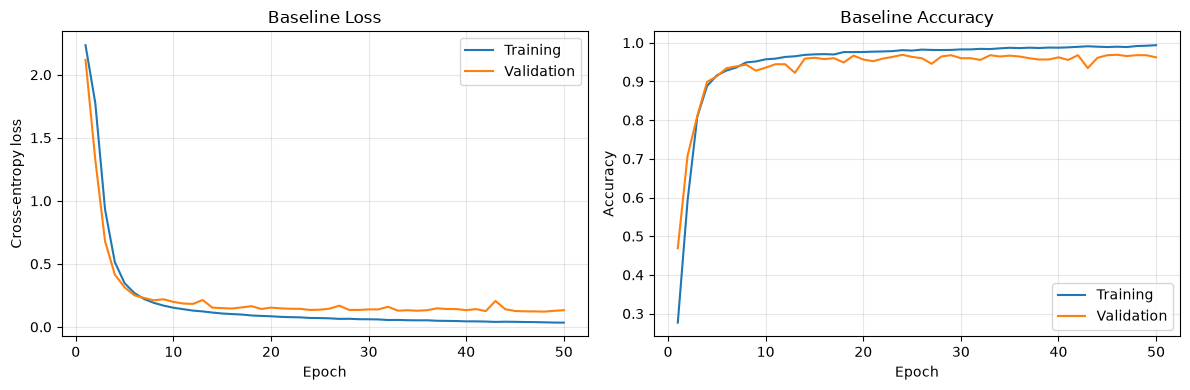

In [44]:
# Evaluate the final baseline model on each data split
def evaluate_model(model, loader):
    model.eval()
    loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for features, labels in loader:
            logits = model(features)
            loss_sum += criterion(logits, labels).item() * labels.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return loss_sum / total, accuracy, 1 - accuracy

# A non-shuffled loader makes the training-set evaluation consistent
train_eval_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False
)

baseline_results = []
for split_name, loader in [
    ("Training", train_eval_loader),
    ("Validation", val_loader),
    ("Test", test_loader)
]:
    loss, accuracy, error = evaluate_model(baseline_model, loader)
    baseline_results.append({
        "Split": split_name,
        "Loss": loss,
        "Accuracy": accuracy,
        "Error Rate": error
    })

baseline_results_df = pd.DataFrame(baseline_results).set_index("Split")
display(baseline_results_df.style.format({
    "Loss": "{:.4f}",
    "Accuracy": "{:.2%}",
    "Error Rate": "{:.2%}"
}))

# Plot learning curves to check convergence and overfitting
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Training")
axes[0].plot(epochs, history["val_loss"], label="Validation")
axes[0].set_title("Baseline Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_accuracy"], label="Training")
axes[1].plot(epochs, history["val_accuracy"], label="Validation")
axes[1].set_title("Baseline Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Improvement Experiments

Each experiment keeps the data split, random seed, batch size, loss function, and hidden-layer sizes fixed. Adam is evaluated first, and the remaining experiments use Adam while adding one technique at a time.

In [45]:
import copy

# Store the metrics from each experiment for the final comparison table.
experiment_results = {}

def reset_experiment_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def train_experiment(model, optimizer, max_epochs=EPOCHS, patience=None, min_delta=1e-4):
    # Recreate the shuffled loader with the same seed for a fair comparison.
    generator = torch.Generator().manual_seed(SEED)
    experiment_train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator
    )

    experiment_history = {
        "train_loss": [], "val_loss": [],
        "train_accuracy": [], "val_accuracy": []
    }
    best_val_loss = np.inf
    best_weights = None
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for features, labels in experiment_train_loader:
            optimizer.zero_grad()
            logits = model(features)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * labels.size(0)
            train_correct += (logits.argmax(dim=1) == labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for features, labels in val_loader:
                logits = model(features)
                loss = criterion(logits, labels)
                val_loss_sum += loss.item() * labels.size(0)
                val_correct += (logits.argmax(dim=1) == labels).sum().item()
                val_total += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_accuracy = train_correct / train_total
        val_loss = val_loss_sum / val_total
        val_accuracy = val_correct / val_total

        experiment_history["train_loss"].append(train_loss)
        experiment_history["val_loss"].append(val_loss)
        experiment_history["train_accuracy"].append(train_accuracy)
        experiment_history["val_accuracy"].append(val_accuracy)

        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch + 1:02d}/{max_epochs} | "
                f"train loss: {train_loss:.4f}, train accuracy: {train_accuracy:.4f} | "
                f"val loss: {val_loss:.4f}, val accuracy: {val_accuracy:.4f}"
            )

        if patience is not None:
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_weights = copy.deepcopy(model.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping after epoch {epoch + 1}; restoring best weights.")
                break

    if patience is not None and best_weights is not None:
        model.load_state_dict(best_weights)

    return experiment_history

def record_and_plot_experiment(name, model, experiment_history):
    split_metrics = {}
    for split_name, loader in [
        ("Train", train_eval_loader),
        ("Validation", val_loader),
        ("Test", test_loader)
    ]:
        loss, accuracy, error = evaluate_model(model, loader)
        split_metrics[split_name] = {
            "Loss": loss, "Accuracy": accuracy, "Error Rate": error
        }

    experiment_results[name] = {
        "Model": name,
        "Train Accuracy": split_metrics["Train"]["Accuracy"],
        "Validation Accuracy": split_metrics["Validation"]["Accuracy"],
        "Test Accuracy": split_metrics["Test"]["Accuracy"],
        "Test Error": split_metrics["Test"]["Error Rate"]
    }

    metrics_df = pd.DataFrame(split_metrics).T
    display(metrics_df.style.format({
        "Loss": "{:.4f}",
        "Accuracy": "{:.2%}",
        "Error Rate": "{:.2%}"
    }))

    epochs = range(1, len(experiment_history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, experiment_history["train_loss"], label="Training")
    axes[0].plot(epochs, experiment_history["val_loss"], label="Validation")
    axes[0].set_title(f"{name}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, experiment_history["train_accuracy"], label="Training")
    axes[1].plot(epochs, experiment_history["val_accuracy"], label="Validation")
    axes[1].set_title(f"{name}: Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### Adam Optimizer

This experiment changes only the optimizer from plain SGD to Adam.

Epoch 01/50 | train loss: 1.4754, train accuracy: 0.6977 | val loss: 0.5594, val accuracy: 0.8822
Epoch 10/50 | train loss: 0.0689, train accuracy: 0.9791 | val loss: 0.1386, val accuracy: 0.9622
Epoch 20/50 | train loss: 0.0296, train accuracy: 0.9936 | val loss: 0.1199, val accuracy: 0.9700
Epoch 30/50 | train loss: 0.0158, train accuracy: 0.9961 | val loss: 0.1227, val accuracy: 0.9689
Epoch 40/50 | train loss: 0.0098, train accuracy: 0.9981 | val loss: 0.1196, val accuracy: 0.9700
Epoch 50/50 | train loss: 0.0114, train accuracy: 0.9964 | val loss: 0.1465, val accuracy: 0.9689


,Loss,Accuracy,Error Rate
Train,0.0059,99.86%,0.14%
Validation,0.1465,96.89%,3.11%
Test,0.0953,97.60%,2.40%


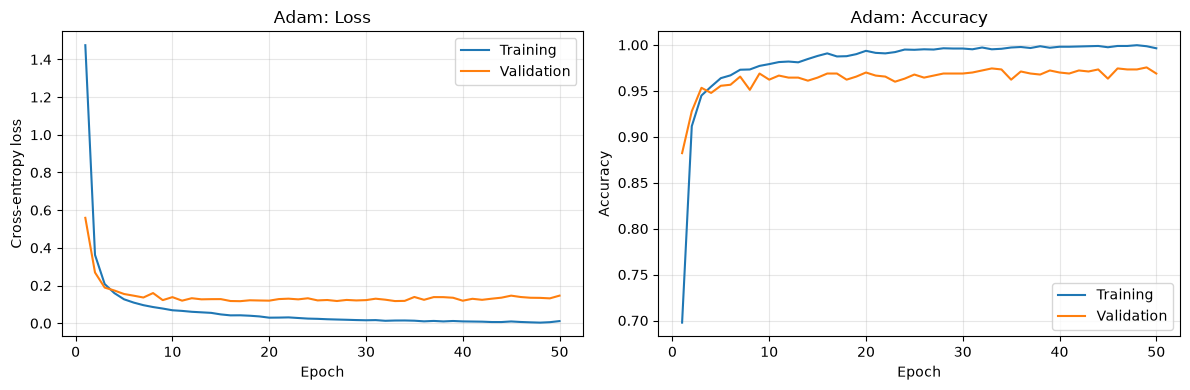

In [46]:
reset_experiment_seed()
adam_model = BaselineMLP()
adam_optimizer = torch.optim.Adam(adam_model.parameters(), lr=0.001)
adam_history = train_experiment(adam_model, adam_optimizer)
record_and_plot_experiment("Adam", adam_model, adam_history)


### L2 Regularization

This experiment uses Adam and adds an L2 penalty through weight decay.

Epoch 01/50 | train loss: 1.4796, train accuracy: 0.6955 | val loss: 0.5618, val accuracy: 0.8822
Epoch 10/50 | train loss: 0.0704, train accuracy: 0.9789 | val loss: 0.1378, val accuracy: 0.9633
Epoch 20/50 | train loss: 0.0322, train accuracy: 0.9917 | val loss: 0.1199, val accuracy: 0.9700
Epoch 30/50 | train loss: 0.0184, train accuracy: 0.9964 | val loss: 0.1144, val accuracy: 0.9711
Epoch 40/50 | train loss: 0.0138, train accuracy: 0.9961 | val loss: 0.1032, val accuracy: 0.9722
Epoch 50/50 | train loss: 0.0139, train accuracy: 0.9958 | val loss: 0.1170, val accuracy: 0.9689


,Loss,Accuracy,Error Rate
Train,0.0098,99.86%,0.14%
Validation,0.1170,96.89%,3.11%
Test,0.0831,97.60%,2.40%


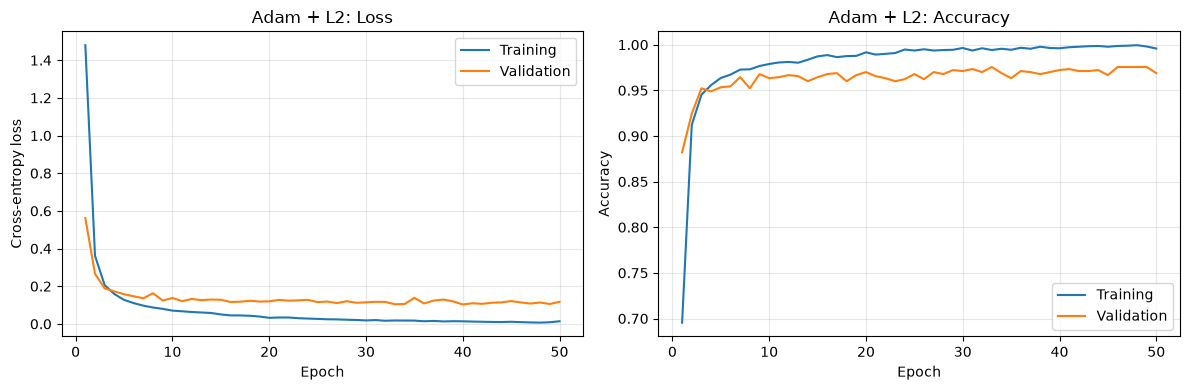

In [47]:
reset_experiment_seed()
l2_model = BaselineMLP()
l2_optimizer = torch.optim.Adam(
    l2_model.parameters(), lr=0.001, weight_decay=1e-4
)
l2_history = train_experiment(l2_model, l2_optimizer)
record_and_plot_experiment("Adam + L2", l2_model, l2_history)


### Dropout

This experiment uses Adam and applies 20% dropout after each hidden activation.

Epoch 01/50 | train loss: 1.6159, train accuracy: 0.5898 | val loss: 0.6852, val accuracy: 0.8356
Epoch 10/50 | train loss: 0.1087, train accuracy: 0.9677 | val loss: 0.1198, val accuracy: 0.9700
Epoch 20/50 | train loss: 0.0585, train accuracy: 0.9814 | val loss: 0.1116, val accuracy: 0.9678
Epoch 30/50 | train loss: 0.0322, train accuracy: 0.9903 | val loss: 0.0930, val accuracy: 0.9756
Epoch 40/50 | train loss: 0.0255, train accuracy: 0.9914 | val loss: 0.0907, val accuracy: 0.9756
Epoch 50/50 | train loss: 0.0210, train accuracy: 0.9917 | val loss: 0.0931, val accuracy: 0.9789


,Loss,Accuracy,Error Rate
Train,0.0061,99.86%,0.14%
Validation,0.0931,97.89%,2.11%
Test,0.0677,98.31%,1.69%


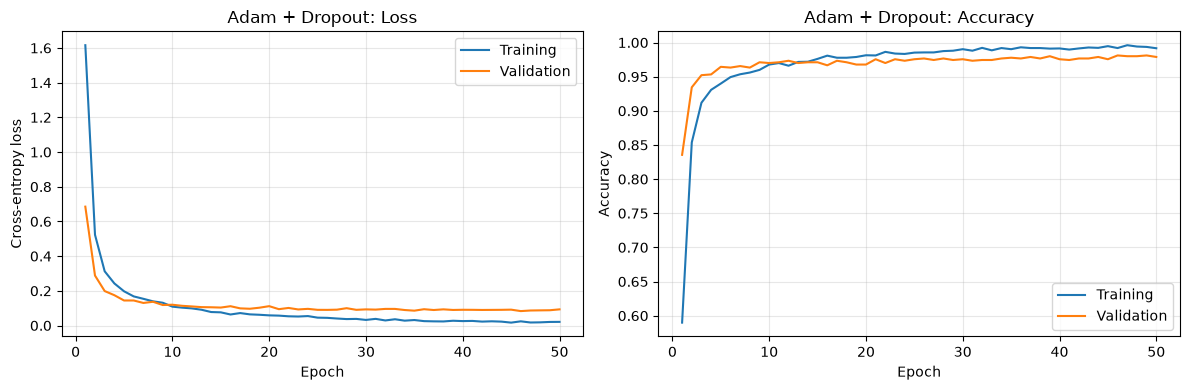

In [48]:
class DropoutMLP(nn.Module):
    def __init__(self, dropout_rate=0.20):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

reset_experiment_seed()
dropout_model = DropoutMLP(dropout_rate=0.20)
dropout_optimizer = torch.optim.Adam(dropout_model.parameters(), lr=0.001)
dropout_history = train_experiment(dropout_model, dropout_optimizer)
record_and_plot_experiment("Adam + Dropout", dropout_model, dropout_history)


### Batch Normalization

This experiment uses Adam and normalizes the output of each hidden linear layer before applying ReLU.

Epoch 01/50 | train loss: 0.8623, train accuracy: 0.8540 | val loss: 0.3269, val accuracy: 0.9700
Epoch 10/50 | train loss: 0.0312, train accuracy: 0.9917 | val loss: 0.0719, val accuracy: 0.9811
Epoch 20/50 | train loss: 0.0123, train accuracy: 0.9967 | val loss: 0.0723, val accuracy: 0.9822
Epoch 30/50 | train loss: 0.0114, train accuracy: 0.9967 | val loss: 0.0598, val accuracy: 0.9867
Epoch 40/50 | train loss: 0.0059, train accuracy: 0.9981 | val loss: 0.0811, val accuracy: 0.9844
Epoch 50/50 | train loss: 0.0019, train accuracy: 1.0000 | val loss: 0.0617, val accuracy: 0.9856


,Loss,Accuracy,Error Rate
Train,0.0002,100.00%,0.00%
Validation,0.0617,98.56%,1.44%
Test,0.0400,98.58%,1.42%


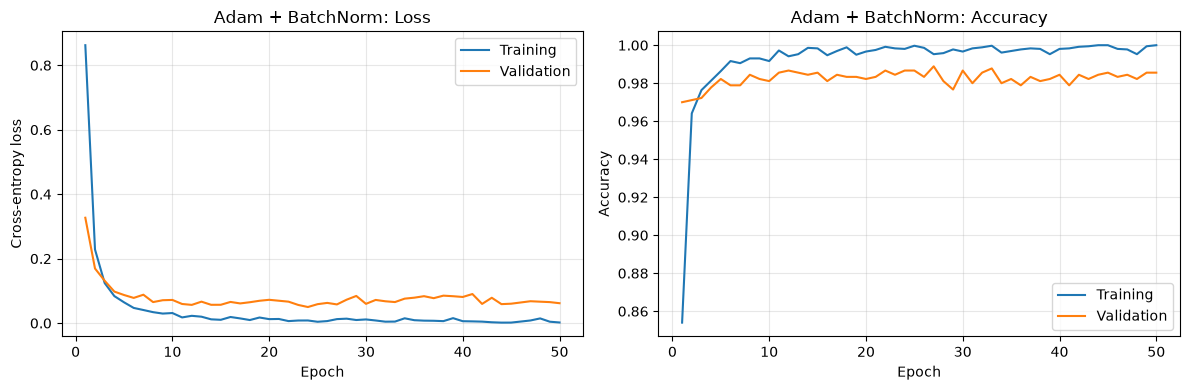

In [49]:
class BatchNormMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

reset_experiment_seed()
batchnorm_model = BatchNormMLP()
batchnorm_optimizer = torch.optim.Adam(batchnorm_model.parameters(), lr=0.001)
batchnorm_history = train_experiment(batchnorm_model, batchnorm_optimizer)
record_and_plot_experiment("Adam + BatchNorm", batchnorm_model, batchnorm_history)


### Early Stopping

This experiment uses Adam and stops after validation loss fails to improve by at least 0.0001 for seven consecutive epochs. The weights from the lowest validation loss are restored.

Epoch 01/50 | train loss: 1.4754, train accuracy: 0.6977 | val loss: 0.5594, val accuracy: 0.8822
Epoch 10/50 | train loss: 0.0689, train accuracy: 0.9791 | val loss: 0.1386, val accuracy: 0.9622
Epoch 20/50 | train loss: 0.0296, train accuracy: 0.9936 | val loss: 0.1199, val accuracy: 0.9700
Early stopping after epoch 24; restoring best weights.


,Loss,Accuracy,Error Rate
Train,0.0325,99.33%,0.67%
Validation,0.1171,96.89%,3.11%
Test,0.0831,97.33%,2.67%


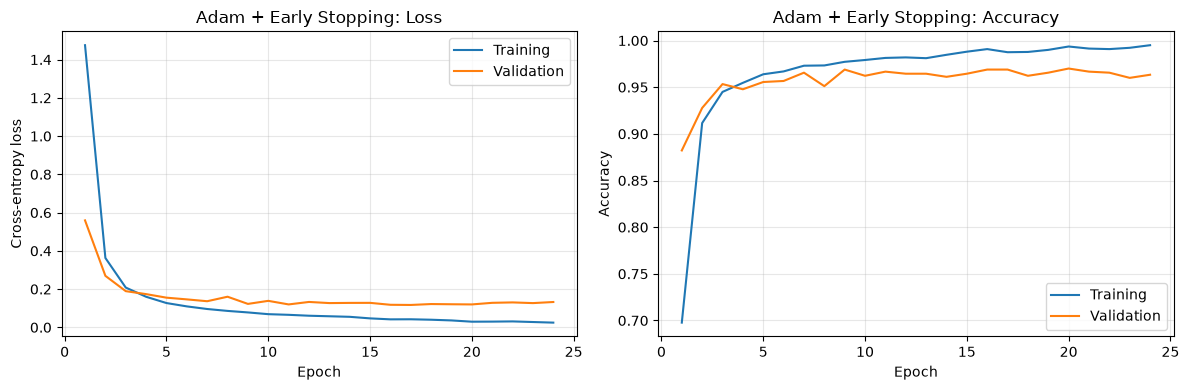

In [50]:
reset_experiment_seed()
early_stopping_model = BaselineMLP()
early_stopping_optimizer = torch.optim.Adam(
    early_stopping_model.parameters(), lr=0.001
)
early_stopping_history = train_experiment(
    early_stopping_model,
    early_stopping_optimizer,
    max_epochs=EPOCHS,
    patience=7
)
record_and_plot_experiment(
    "Adam + Early Stopping", early_stopping_model, early_stopping_history
)


## Experiment Comparison

The final model should be chosen using validation performance rather than test performance. Test results are included to report the required generalization error after all experiment configurations have been fixed.

,Train Accuracy,Validation Accuracy,Test Accuracy,Test Error,Train-Test Gap,Accuracy Change vs. Baseline,Relative Error Reduction
Model,,,,,,,
Baseline (SGD),99.22%,96.22%,96.89%,3.11%,2.34%,0.00%,0.00%
Adam,99.86%,96.89%,97.60%,2.40%,2.26%,0.71%,22.86%
Adam + L2,99.86%,96.89%,97.60%,2.40%,2.26%,0.71%,22.86%
Adam + Dropout,99.86%,97.89%,98.31%,1.69%,1.55%,1.42%,45.71%
Adam + BatchNorm,100.00%,98.56%,98.58%,1.42%,1.42%,1.69%,54.29%
Adam + Early Stopping,99.33%,96.89%,97.33%,2.67%,2.00%,0.44%,14.29%


Best validation accuracy: Adam + BatchNorm


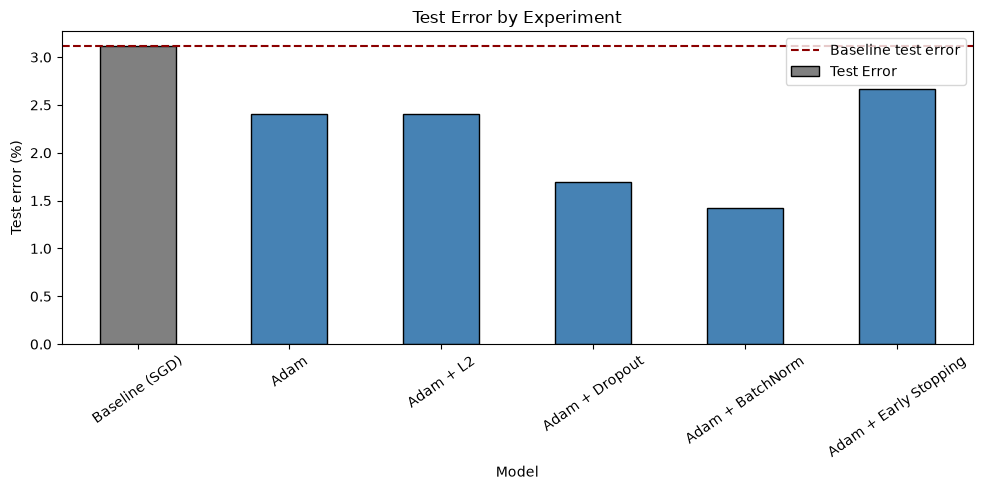

In [51]:
baseline_row = {
    "Model": "Baseline (SGD)",
    "Train Accuracy": baseline_results_df.loc["Training", "Accuracy"],
    "Validation Accuracy": baseline_results_df.loc["Validation", "Accuracy"],
    "Test Accuracy": baseline_results_df.loc["Test", "Accuracy"],
    "Test Error": baseline_results_df.loc["Test", "Error Rate"]
}

experiment_order = [
    "Adam",
    "Adam + L2",
    "Adam + Dropout",
    "Adam + BatchNorm",
    "Adam + Early Stopping"
]
summary_rows = [baseline_row] + [experiment_results[name] for name in experiment_order]
comparison_df = pd.DataFrame(summary_rows).set_index("Model")

comparison_df["Train-Test Gap"] = (
    comparison_df["Train Accuracy"] - comparison_df["Test Accuracy"]
)
baseline_test_accuracy = comparison_df.loc["Baseline (SGD)", "Test Accuracy"]
baseline_test_error = comparison_df.loc["Baseline (SGD)", "Test Error"]
comparison_df["Accuracy Change vs. Baseline"] = (
    comparison_df["Test Accuracy"] - baseline_test_accuracy
)
comparison_df["Relative Error Reduction"] = (
    (baseline_test_error - comparison_df["Test Error"]) / baseline_test_error
)

percentage_columns = {column: "{:.2%}" for column in comparison_df.columns}
display(comparison_df.style.format(percentage_columns))

best_validation_model = comparison_df["Validation Accuracy"].idxmax()
print(f"Best validation accuracy: {best_validation_model}")

ax = (comparison_df["Test Error"] * 100).plot(
    kind="bar",
    figsize=(10, 5),
    color=["gray"] + ["steelblue"] * len(experiment_order),
    edgecolor="black"
)
ax.axhline(
    baseline_test_error * 100,
    color="darkred",
    linestyle="--",
    label="Baseline test error"
)
ax.set_title("Test Error by Experiment")
ax.set_xlabel("Model")
ax.set_ylabel("Test error (%)")
ax.tick_params(axis="x", rotation=35)
ax.legend()
plt.tight_layout()
plt.show()


Here we can see that L2, and early stopping did not significantly improve the test error. However, the Adam optimizer, Dropout, and BatchNorm all significantly improved performance.

## Final Model

Epoch 01/50 | train loss: 1.0647, train accuracy: 0.7798 | val loss: 0.4141, val accuracy: 0.9644
Epoch 10/50 | train loss: 0.0804, train accuracy: 0.9775 | val loss: 0.0667, val accuracy: 0.9811
Epoch 20/50 | train loss: 0.0397, train accuracy: 0.9867 | val loss: 0.0557, val accuracy: 0.9844
Epoch 30/50 | train loss: 0.0359, train accuracy: 0.9869 | val loss: 0.0635, val accuracy: 0.9844
Epoch 40/50 | train loss: 0.0299, train accuracy: 0.9897 | val loss: 0.0725, val accuracy: 0.9800
Epoch 50/50 | train loss: 0.0200, train accuracy: 0.9930 | val loss: 0.0799, val accuracy: 0.9767


,Loss,Accuracy,Error Rate
Train,0.0014,99.94%,0.06%
Validation,0.0799,97.67%,2.33%
Test,0.0408,98.58%,1.42%


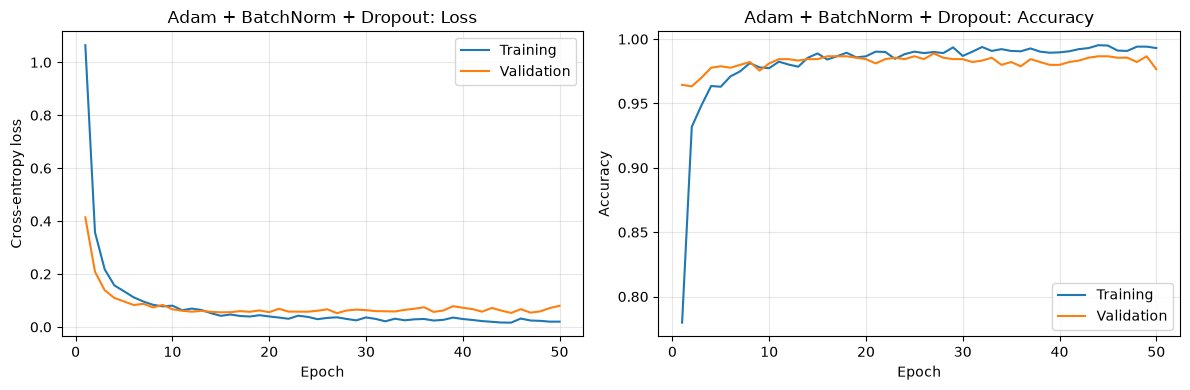

In [53]:
class CombinedMLP(nn.Module):
    def __init__(self, dropout_rate=0.20):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

# Combine the three techniques that improved validation performance:
# Adam, batch normalization, and dropout.
reset_experiment_seed()
combined_model = CombinedMLP(dropout_rate=0.20)
combined_optimizer = torch.optim.Adam(
    combined_model.parameters(), lr=0.001
)
combined_history = train_experiment(
    combined_model, combined_optimizer, max_epochs=EPOCHS
)
record_and_plot_experiment(
    "Adam + BatchNorm + Dropout", combined_model, combined_history
)


### Final Model Comparison

The combined candidate is compared with the unregularized baseline and every individual improvement experiment. The final model should be selected primarily by validation performance.

,Train Accuracy,Validation Accuracy,Test Accuracy,Test Error,Train-Test Gap,Accuracy Change vs. Baseline,Relative Error Reduction
Model,,,,,,,
Baseline (SGD),99.22%,96.22%,96.89%,3.11%,2.34%,0.00%,0.00%
Adam,99.86%,96.89%,97.60%,2.40%,2.26%,0.71%,22.86%
Adam + L2,99.86%,96.89%,97.60%,2.40%,2.26%,0.71%,22.86%
Adam + Dropout,99.86%,97.89%,98.31%,1.69%,1.55%,1.42%,45.71%
Adam + BatchNorm,100.00%,98.56%,98.58%,1.42%,1.42%,1.69%,54.29%
Adam + Early Stopping,99.33%,96.89%,97.33%,2.67%,2.00%,0.44%,14.29%
Adam + BatchNorm + Dropout,99.94%,97.67%,98.58%,1.42%,1.37%,1.69%,54.29%


Best model by validation accuracy: Adam + BatchNorm
Combined model validation change relative to BatchNorm alone: -0.89%


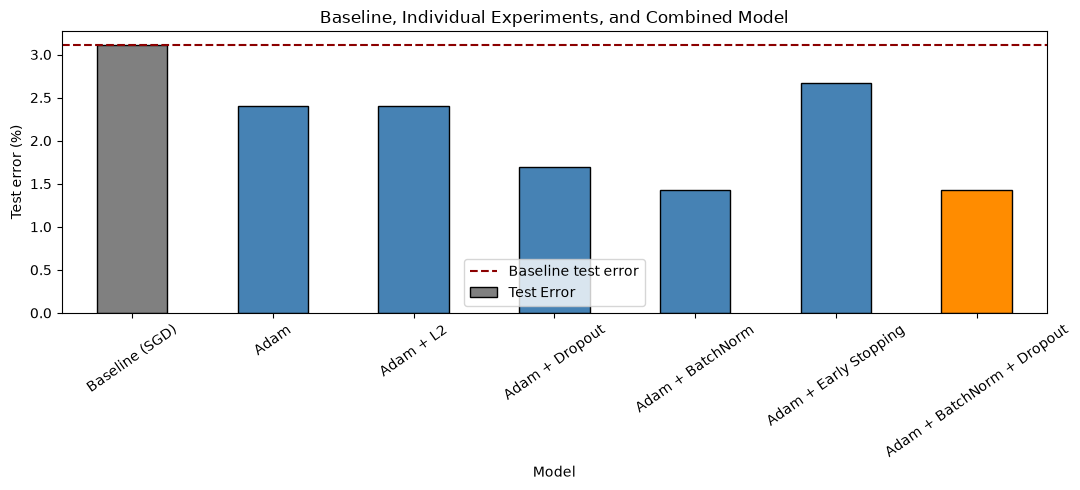

In [55]:
combined_name = "Adam + BatchNorm + Dropout"
final_summary_rows = (
    [baseline_row]
    + [experiment_results[name] for name in experiment_order]
    + [experiment_results[combined_name]]
)
final_comparison_df = pd.DataFrame(final_summary_rows).set_index("Model")

final_comparison_df["Train-Test Gap"] = (
    final_comparison_df["Train Accuracy"]
    - final_comparison_df["Test Accuracy"]
)
baseline_test_accuracy = final_comparison_df.loc[
    "Baseline (SGD)", "Test Accuracy"
]
baseline_test_error = final_comparison_df.loc[
    "Baseline (SGD)", "Test Error"
]
final_comparison_df["Accuracy Change vs. Baseline"] = (
    final_comparison_df["Test Accuracy"] - baseline_test_accuracy
)
final_comparison_df["Relative Error Reduction"] = (
    (baseline_test_error - final_comparison_df["Test Error"])
    / baseline_test_error
)

percentage_columns = {
    column: "{:.2%}" for column in final_comparison_df.columns
}
display(final_comparison_df.style.format(percentage_columns))

best_validation_model = final_comparison_df["Validation Accuracy"].idxmax()
combined_val_change = (
    final_comparison_df.loc[combined_name, "Validation Accuracy"]
    - final_comparison_df.loc["Adam + BatchNorm", "Validation Accuracy"]
)
print(f"Best model by validation accuracy: {best_validation_model}")
print(
    "Combined model validation change relative to BatchNorm alone: "
    f"{combined_val_change:+.2%}"
)

colors = [
    "gray" if name == "Baseline (SGD)"
    else "darkorange" if name == combined_name
    else "steelblue"
    for name in final_comparison_df.index
]
ax = (final_comparison_df["Test Error"] * 100).plot(
    kind="bar",
    figsize=(11, 5),
    color=colors,
    edgecolor="black"
)
ax.axhline(
    baseline_test_error * 100,
    color="darkred",
    linestyle="--",
    label="Baseline test error"
)
ax.set_title("Baseline, Individual Experiments, and Combined Model")
ax.set_xlabel("Model")
ax.set_ylabel("Test error (%)")
ax.tick_params(axis="x", rotation=35)
ax.legend()
plt.tight_layout()
plt.show()


The final model with Adam + BatchNorm + Dropout performed identical to Adam + BatchNorm, both of which have the lowest test error of the tested regularization combinations. Thus, the best model to use here is Adam + BatchNorm for its performance and simplicity.